In [1]:
import sys
from pathlib import Path
import os
import pandas as pd
sys.path.append(str(Path.cwd().parent))
DATA_DIR = os.path.join(os.getcwd(), "..", "data")

In [1]:
from src.load_data import get_moex_candles, save_candles_df
from datetime import datetime
start_date = datetime(2013, 1, 1)
end_date = datetime(2026, 3, 11)
ticker = "IMOEX"

candles = get_moex_candles(ticker, start_date, end_date, rest_time=0.5, interval=10, market="index")
save_candles_df(candles, "IMOEX.csv")

ModuleNotFoundError: No module named 'src'

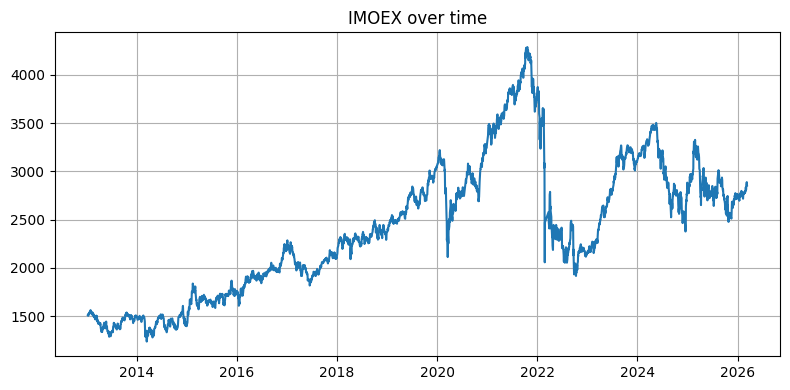

In [2]:
candles = pd.read_csv(os.path.join(DATA_DIR, "IMOEX.csv"))
candles['end'] = pd.to_datetime(candles['end'])
candles.set_index('end', inplace=True)
candles = candles.resample("D").agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'  
}).dropna()

from matplotlib import pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(candles.index, candles['close'])
plt.title("IMOEX over time")
plt.grid()
plt.tight_layout()

In [3]:
from src.get_features import add_log_returns, add_volatility

candles = add_log_returns(candles, [1, 7, 14, 30, 90])
candles = add_volatility(candles, [7, 14, 30, 90])

Model is not converging.  Current: 83789.41127544145 is not greater than 83789.69096594861. Delta is -0.2796905071591027
Model is not converging.  Current: 83376.0691098497 is not greater than 83376.21186410627. Delta is -0.1427542565652402
Model is not converging.  Current: 84943.01448810742 is not greater than 84943.05550154718. Delta is -0.04101343975344207
Model is not converging.  Current: 83862.20130274225 is not greater than 83862.48483060824. Delta is -0.2835278659913456
Model is not converging.  Current: 85029.86198096252 is not greater than 85029.86255496881. Delta is -0.0005740062915720046
Model is not converging.  Current: 84355.2930340405 is not greater than 84398.33002535408. Delta is -43.036991313580074
Model is not converging.  Current: 84791.75049780145 is not greater than 84815.3965575205. Delta is -23.646059719045297
Model is not converging.  Current: 85129.93844073967 is not greater than 85129.98241633247. Delta is -0.043975592794595286
Model is not converging.  Cur

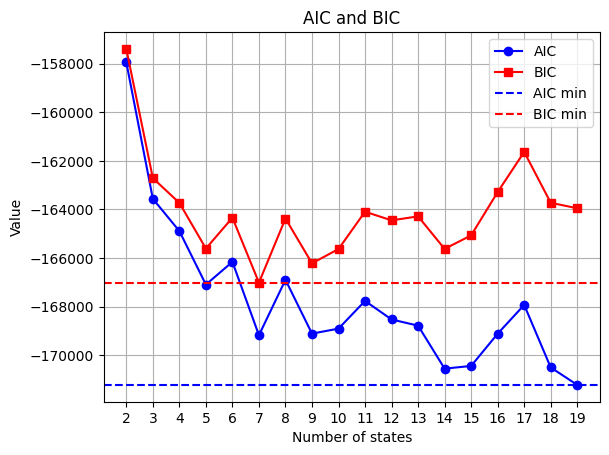

In [24]:
from src.train_hmm import train_hmm
features = [
    "log_returns_7", "log_returns_14", "log_returns_30", "log_returns_90",
    "volatility_7", "volatility_14", "volatility_30", "volatility_90"
]

candles = candles.dropna()
X = candles[features].values

bics = []
aics = []
ks = range(2, 20)
for k in ks:
    model = train_hmm(X, n_states=k, n_iter=5000)
    bics.append(model.bic(X))
    aics.append(model.aic(X))

plt.plot(ks, aics, marker='o', label='AIC', color='blue')
plt.plot(ks, bics, marker='s', label='BIC', color='red')

min_aic = min(aics)
min_bic = min(bics)
plt.axhline(min_aic, linestyle='--', label='AIC min', color='blue')
plt.axhline(min_bic, linestyle='--', label='BIC min', color='red')

plt.xlabel('Number of states')
plt.ylabel('Value')
plt.title('AIC and BIC')
plt.grid()
plt.xticks(ks)
plt.legend()
plt.show()

In [5]:
model = train_hmm(X, n_states=3, n_iter=5000)

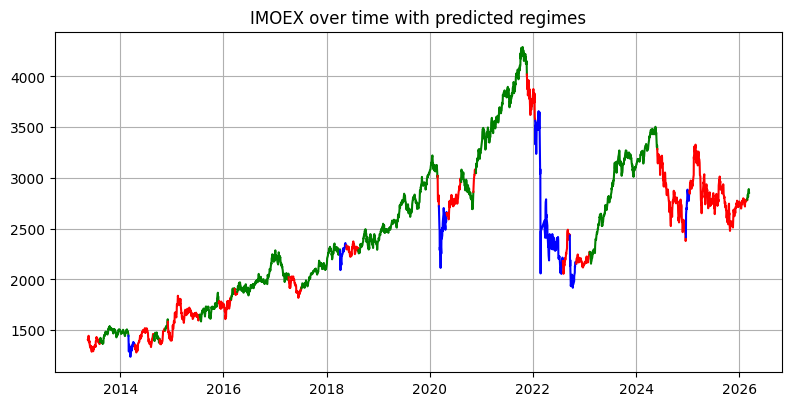

In [6]:
from src.visualization import plot_price_with_regimes
regimes = model.predict(X)
dates = candles.index
prices = candles['close'].values

plot_price_with_regimes(prices, dates, regimes)

In [7]:
candles['regime'] = regimes
statistics = candles.groupby('regime').agg({
    'log_returns_7': ['mean', 'std'],
    'volatility_7': ['mean', 'std'],
    'close':['count']
})

print(statistics)

       log_returns_7           volatility_7           close
                mean       std         mean       std count
regime                                                     
0           0.005612  0.022723     0.007986  0.003032  1779
1          -0.000533  0.036995     0.012135  0.005123  1180
2          -0.017038  0.093090     0.027970  0.027538   261


[[9.93672995e-01 5.20114502e-03 1.12585988e-03]
 [1.02909462e-02 9.86325771e-01 3.38328246e-03]
 [5.84240500e-98 2.30487711e-02 9.76951229e-01]]


Text(50.722222222222214, 0.5, 'from')

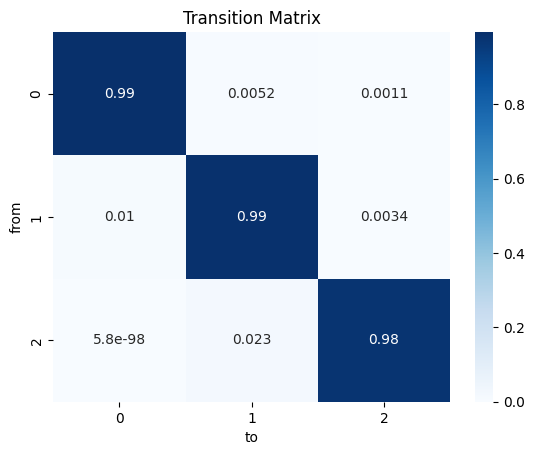

In [8]:
import seaborn as sns
sns.heatmap(model.transmat_, annot=True, cmap="Blues")
print(model.transmat_)
plt.title("Transition Matrix")
plt.xlabel("to")
plt.ylabel("from")

In [9]:
import numpy as np
trans = model.transmat_
expected_duration = 1 / (1 - np.diag(trans))
df = pd.DataFrame({
    "Stay Probability": np.diag(trans),
    "Expected regime duration (days)": expected_duration
})
print(df)

   Stay Probability  Expected regime duration (days)
0          0.993673                       158.052667
1          0.986326                        73.130268
2          0.976951                        43.386261
